# Recup données parcellaires

In [1]:
import requests
import geopandas as gpd
import polars as pl
import io
import seaborn as sns
import fiona
import pandas as pd
import matplotlib.pyplot as plt

from config import code_region_rpg

In [2]:
# Definition de la région 
region = "Pays de la Loire"  # None

In [3]:
# Definition des fichiers de données
admin_file = "../../data/raw/ADE_4-0_GPKG_LAMB93_FXX-ED2026-02-16.gpkg"
admin_file_sm = "../../data/raw/ADE-COG-CARTOPLUS_4-0_GPKG_LAMB93_FRA-ED2025-01-01.gpkg"

In [4]:
# Chargement des données de RPG
if region:
    # Mapping du fichier
    code = code_region_rpg[region]
    rpg_filepath = f"../../data/raw/RPG_3-0__GPKG_LAMB93_R{code}_2024-01-01/RPG_Parcelles.gpkg"
else: 
    # RPG national
    rpg_filepath = "../../data/raw/RPG_3-0__GPKG_LAMB93_FXX_2024-01-01/RPG_Parcelles.gpkg"

### Import et formatage des données administratives

In [5]:
# Exploration des couches
gpkg_path = admin_file_sm
for layer in fiona.listlayers(gpkg_path):
    print(layer)

canton
arrondissement
arrondissement_municipal
chef_lieu_d_arrondissement
chef_lieu_d_arrondissement_municipal
chef_lieu_de_canton
chef_lieu_de_collectivite_territoriale
chef_lieu_de_commune
chef_lieu_de_commune_associee_ou_deleguee
chef_lieu_de_departement
chef_lieu_d_epci
chef_lieu_de_region
collectivite_territoriale
commune
commune_associee_ou_deleguee
departement
epci
region
info_metadonnees
layer_styles


In [6]:
# Régions
regions = gpd.read_file(gpkg_path, layer="REGION")
regions.columns

Index(['cleabs', 'nom_officiel', 'nom_officiel_en_majuscules', 'code_insee',
       'code_siren', 'geometry'],
      dtype='object')

In [7]:
# Départements
departements = gpd.read_file(gpkg_path, layer="DEPARTEMENT")
departements.columns

Index(['cleabs', 'nom_officiel', 'nom_officiel_en_majuscules', 'code_insee',
       'code_insee_de_la_region', 'code_siren', 'geometry'],
      dtype='object')

In [8]:
# Communes
communes = gpd.read_file(gpkg_path, layer="COMMUNE")
communes.columns

Index(['cleabs', 'nom_officiel', 'nom_officiel_en_majuscules', 'statut',
       'code_insee', 'population', 'date_du_recensement',
       'organisme_recenseur', 'code_insee_du_canton',
       'code_insee_de_l_arrondissement', 'code_insee_du_departement',
       'code_insee_de_la_region', 'codes_siren_des_epci', 'code_siren',
       'code_postal', 'superficie_cadastrale', 'geometry'],
      dtype='object')

In [9]:
# Représenation de la taille des communes
communes["superficie_cadastrale_km2"] = communes["superficie_cadastrale"] * 0.01 # Convertir hectares en km2
communes["superficie_cadastrale_km2"].describe()
# Part des communes de moins de 81 km²
small_communes = communes[communes["superficie_cadastrale_km2"] < 81]
print(f"Nombre de communes de moins de 10 km² : {len(small_communes)} sur {len(communes)} ({len(small_communes)/len(communes)*100:.2f}%)")

Nombre de communes de moins de 10 km² : 34477 sur 34879 (98.85%)


In [10]:
# Selection des colonnes
communes_cols = ['cleabs', 'nom_officiel', 'nom_officiel_en_majuscules', 
       'code_insee', 'population', 'code_insee_du_departement',
       'code_insee_de_la_region', 'code_siren',
       'code_postal', 'superficie_cadastrale', 'geometry']
dep_cols= ['nom_officiel', 'nom_officiel_en_majuscules', 'code_insee',
       'code_insee_de_la_region', 'code_siren', 'geometry']
region_cols = ['nom_officiel', 'nom_officiel_en_majuscules', 'code_insee',
       'code_siren', 'geometry']

In [11]:
# Département → Région
dep_reg = departements[dep_cols].merge(
    regions[region_cols],
    left_on="code_insee_de_la_region",
    right_on="code_insee",
    suffixes=('_dep', '_reg')
)

In [12]:
# Communes → Département → Région
communes_enrichies = communes[communes_cols].merge(
        dep_reg,
        left_on="code_insee_du_departement",
        right_on='code_insee_dep',
        suffixes=('_commune', '')
    )

In [13]:
communes_enrichies.columns

Index(['cleabs', 'nom_officiel', 'nom_officiel_en_majuscules', 'code_insee',
       'population', 'code_insee_du_departement',
       'code_insee_de_la_region_commune', 'code_siren', 'code_postal',
       'superficie_cadastrale', 'geometry', 'nom_officiel_dep',
       'nom_officiel_en_majuscules_dep', 'code_insee_dep',
       'code_insee_de_la_region', 'code_siren_dep', 'geometry_dep',
       'nom_officiel_reg', 'nom_officiel_en_majuscules_reg', 'code_insee_reg',
       'code_siren_reg', 'geometry_reg'],
      dtype='object')

In [14]:
# Formatage
communes_enrichies.head()

,cleabs,nom_officiel,nom_officiel_en_majuscules,code_insee,population,code_insee_du_departement,code_insee_de_la_region_commune,code_siren,code_postal,superficie_cadastrale,...,nom_officiel_en_majuscules_dep,code_insee_dep,code_insee_de_la_region,code_siren_dep,geometry_dep,nom_officiel_reg,nom_officiel_en_majuscules_reg,code_insee_reg,code_siren_reg,geometry_reg
0,COMMUNE_0000000000001001,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,01001,859,01,84,210100012,01400,1590.0,...,AIN,01,84,220100010,"MULTIPOLYGON (((839587.4 6537464.4, 838967.5 6...",Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767,"MULTIPOLYGON (((634116.9 6394585.4, 634578.8 6..."
1,COMMUNE_0000000000001002,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,01002,273,01,84,210100020,01640,920.0,...,AIN,01,84,220100010,"MULTIPOLYGON (((839587.4 6537464.4, 838967.5 6...",Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767,"MULTIPOLYGON (((634116.9 6394585.4, 634578.8 6..."
2,COMMUNE_0000000000001004,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,01004,15554,01,84,210100046,01500,2460.0,...,AIN,01,84,220100010,"MULTIPOLYGON (((839587.4 6537464.4, 838967.5 6...",Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767,"MULTIPOLYGON (((634116.9 6394585.4, 634578.8 6..."
3,COMMUNE_0000000000001005,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,01005,1917,01,84,210100053,01330,1590.0,...,AIN,01,84,220100010,"MULTIPOLYGON (((839587.4 6537464.4, 838967.5 6...",Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767,"MULTIPOLYGON (((634116.9 6394585.4, 634578.8 6..."
4,COMMUNE_0000000000001006,Ambléon,AMBLEON,01006,114,01,84,210100061,01300,590.0,...,AIN,01,84,220100010,"MULTIPOLYGON (((839587.4 6537464.4, 838967.5 6...",Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767,"MULTIPOLYGON (((634116.9 6394585.4, 634578.8 6..."


In [15]:
# Sauvegarde du fichier administratif
geom_cols = ["geometry", "geometry_dep", "geometry_reg"]
df_communes_admin = pd.DataFrame(communes_enrichies.drop(columns=geom_cols))
df_communes_admin.head()

,cleabs,nom_officiel,nom_officiel_en_majuscules,code_insee,population,code_insee_du_departement,code_insee_de_la_region_commune,code_siren,code_postal,superficie_cadastrale,nom_officiel_dep,nom_officiel_en_majuscules_dep,code_insee_dep,code_insee_de_la_region,code_siren_dep,nom_officiel_reg,nom_officiel_en_majuscules_reg,code_insee_reg,code_siren_reg
0,COMMUNE_0000000000001001,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,01001,859,01,84,210100012,01400,1590.0,Ain,AIN,01,84,220100010,Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767
1,COMMUNE_0000000000001002,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,01002,273,01,84,210100020,01640,920.0,Ain,AIN,01,84,220100010,Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767
2,COMMUNE_0000000000001004,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,01004,15554,01,84,210100046,01500,2460.0,Ain,AIN,01,84,220100010,Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767
3,COMMUNE_0000000000001005,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,01005,1917,01,84,210100053,01330,1590.0,Ain,AIN,01,84,220100010,Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767
4,COMMUNE_0000000000001006,Ambléon,AMBLEON,01006,114,01,84,210100061,01300,590.0,Ain,AIN,01,84,220100010,Auvergne-Rhône-Alpes,AUVERGNE-RHONE-ALPES,84,200053767


In [16]:
df_communes_admin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34911 entries, 0 to 34910
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   cleabs                           34911 non-null  object 
 1   nom_officiel                     34911 non-null  object 
 2   nom_officiel_en_majuscules       34911 non-null  object 
 3   code_insee                       34911 non-null  object 
 4   population                       34911 non-null  int32  
 5   code_insee_du_departement        34911 non-null  object 
 6   code_insee_de_la_region_commune  34911 non-null  object 
 7   code_siren                       34911 non-null  object 
 8   code_postal                      34908 non-null  object 
 9   superficie_cadastrale            34893 non-null  float64
 10  nom_officiel_dep                 34911 non-null  object 
 11  nom_officiel_en_majuscules_dep   34911 non-null  object 
 12  code_insee_dep    

In [17]:
# Forcer les types avant la sauvegarde
# Colonnes à convertir en int (adapter selon ton df)
int_cols = ["population", "code_postal"]
float_cols = ["superficie_cadastrale"]

df_communes_admin[int_cols] = df_communes_admin[int_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")
df_communes_admin[float_cols] = df_communes_admin[float_cols].apply(pd.to_numeric, errors="coerce")

In [18]:
pl.from_pandas(df_communes_admin).write_parquet("../../data/fichier_admin_communes.parquet")

## Données parcellaires de l'IGN

In [19]:
# Import du fichier de données parcellaires Pays de la Loire
gdf_rpg = gpd.read_file(rpg_filepath)

In [20]:
# Type des données
gdf_rpg.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 730918 entries, 0 to 730917
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id_parcel   730918 non-null  object  
 1   surf_parc   730918 non-null  float64 
 2   code_cultu  730918 non-null  object  
 3   code_group  730918 non-null  object  
 4   culture_d1  6715 non-null    object  
 5   culture_d2  6689 non-null    object  
 6   cat_cult_p  671468 non-null  object  
 7   geometry    730918 non-null  geometry
dtypes: float64(1), geometry(1), object(6)
memory usage: 44.6+ MB


In [21]:
# Formatage des données
cat_cols = ['code_cultu', 'code_group', 'culture_d1', 'culture_d2', 'cat_cult_p']
gdf_rpg[cat_cols] = gdf_rpg[cat_cols].astype('category')
gdf_rpg.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 730918 entries, 0 to 730917
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id_parcel   730918 non-null  object  
 1   surf_parc   730918 non-null  float64 
 2   code_cultu  730918 non-null  category
 3   code_group  730918 non-null  category
 4   culture_d1  6715 non-null    category
 5   culture_d2  6689 non-null    category
 6   cat_cult_p  671468 non-null  category
 7   geometry    730918 non-null  geometry
dtypes: category(5), float64(1), geometry(1), object(1)
memory usage: 20.9+ MB


In [22]:
# Exploration des données
gdf_rpg.describe(include = "all")

,id_parcel,surf_parc,code_cultu,code_group,culture_d1,culture_d2,cat_cult_p,geometry
count,730918,730918.000000,730918,730918,6715,6689,671468,730918
unique,730884,NaN,132,22,31,35,5,730884
top,10863865,NaN,PPH,18,DPH,DTR,TA,MULTIPOLYGON (((432826.8250999973 6779414.6739...
freq,3,NaN,237050,237041,1283,1998,368550,3
mean,NaN,2.819533,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,3.684724,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.430000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.660000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.830000,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Assure-toi que les CRS sont identiques (les deux sont en LAMB93 normalement)
print(gdf_rpg.crs, communes.crs)

EPSG:2154 EPSG:2154


In [24]:
# Jointure spatiale parcelles → communes
rpg_avec_admin = gpd.sjoin(
    gdf_rpg,
    communes_enrichies,
    how='left',
    predicate='within'
)

In [25]:
# Visualisation des premieres lignes
print(rpg_avec_admin.head())
print(rpg_avec_admin.columns.tolist())

  id_parcel  surf_parc code_cultu code_group culture_d1 culture_d2 cat_cult_p  \
0   5460010        0.0        AAR         24        NaN        NaN         TA   
1   9220590        0.0        AAR         24        NaN        NaN         TA   
2   3794564        0.0        AAR         24        NaN        NaN         TA   
3   3794565        0.0        AAR         24        NaN        NaN         TA   
4   3936533        0.0        AAR         24        NaN        NaN         TA   

                                            geometry  index_right  \
0  MULTIPOLYGON (((504952.253 6769144.517, 504965...      28563.0   
1  MULTIPOLYGON (((504953.972 6769142.862, 504953...      28563.0   
2  MULTIPOLYGON (((504979.834 6769163.53, 504977....      28563.0   
3  MULTIPOLYGON (((504979.834 6769163.53, 504979....      28563.0   
4  MULTIPOLYGON (((504989.344 6769163.469, 504989...      28563.0   

                     cleabs  ... nom_officiel_en_majuscules_dep  \
0  COMMUNE_0000000000072300  ..

In [26]:
print("Regions:", rpg_avec_admin.nom_officiel_reg.unique())
print("Départements:", rpg_avec_admin.nom_officiel_dep.unique())

Regions: ['Pays de la Loire' 'Normandie' nan 'Centre-Val de Loire' 'Bretagne'
 'Nouvelle-Aquitaine']
Départements: ['Sarthe' 'Maine-et-Loire' 'Vendée' 'Loire-Atlantique' 'Orne' 'Mayenne'
 nan 'Indre-et-Loire' 'Ille-et-Vilaine' 'Morbihan' 'Charente-Maritime'
 'Loir-et-Cher' 'Deux-Sèvres' 'Manche' 'Eure-et-Loir' 'Vienne']


In [27]:
rpg_avec_admin.columns

Index(['id_parcel', 'surf_parc', 'code_cultu', 'code_group', 'culture_d1',
       'culture_d2', 'cat_cult_p', 'geometry', 'index_right', 'cleabs',
       'nom_officiel', 'nom_officiel_en_majuscules', 'code_insee',
       'population', 'code_insee_du_departement',
       'code_insee_de_la_region_commune', 'code_siren', 'code_postal',
       'superficie_cadastrale', 'nom_officiel_dep',
       'nom_officiel_en_majuscules_dep', 'code_insee_dep',
       'code_insee_de_la_region', 'code_siren_dep', 'geometry_dep',
       'nom_officiel_reg', 'nom_officiel_en_majuscules_reg', 'code_insee_reg',
       'code_siren_reg', 'geometry_reg'],
      dtype='object')

In [28]:
# Sauvegarde du fichier enrichi
geom_cols = ["geometry", "geometry_dep", "geometry_reg"]
df_rpg_avec_admin = pd.DataFrame(rpg_avec_admin.drop(columns=geom_cols))
df_rpg_avec_admin.head()

,id_parcel,surf_parc,code_cultu,code_group,culture_d1,culture_d2,cat_cult_p,index_right,cleabs,nom_officiel,...,superficie_cadastrale,nom_officiel_dep,nom_officiel_en_majuscules_dep,code_insee_dep,code_insee_de_la_region,code_siren_dep,nom_officiel_reg,nom_officiel_en_majuscules_reg,code_insee_reg,code_siren_reg
0,5460010,0.0,AAR,24,NaN,NaN,TA,28563.0,COMMUNE_0000000000072300,Saint-Mars-la-Brière,...,3470.0,Sarthe,SARTHE,72,52,227200029,Pays de la Loire,PAYS DE LA LOIRE,52,234400034
1,9220590,0.0,AAR,24,NaN,NaN,TA,28563.0,COMMUNE_0000000000072300,Saint-Mars-la-Brière,...,3470.0,Sarthe,SARTHE,72,52,227200029,Pays de la Loire,PAYS DE LA LOIRE,52,234400034
2,3794564,0.0,AAR,24,NaN,NaN,TA,28563.0,COMMUNE_0000000000072300,Saint-Mars-la-Brière,...,3470.0,Sarthe,SARTHE,72,52,227200029,Pays de la Loire,PAYS DE LA LOIRE,52,234400034
3,3794565,0.0,AAR,24,NaN,NaN,TA,28563.0,COMMUNE_0000000000072300,Saint-Mars-la-Brière,...,3470.0,Sarthe,SARTHE,72,52,227200029,Pays de la Loire,PAYS DE LA LOIRE,52,234400034
4,3936533,0.0,AAR,24,NaN,NaN,TA,28563.0,COMMUNE_0000000000072300,Saint-Mars-la-Brière,...,3470.0,Sarthe,SARTHE,72,52,227200029,Pays de la Loire,PAYS DE LA LOIRE,52,234400034


In [29]:
# Sauvegarde du fichier enrichi
if region:
    pl.from_pandas(df_rpg_avec_admin).write_parquet(f"../../data/fichier_rpg_communes_reg{code}.parquet")
else: 
    pl.from_pandas(df_rpg_avec_admin).write_parquet(f"../../data/fichier_rpg_communes.parquet")

<Axes: xlabel='surf_parc'>

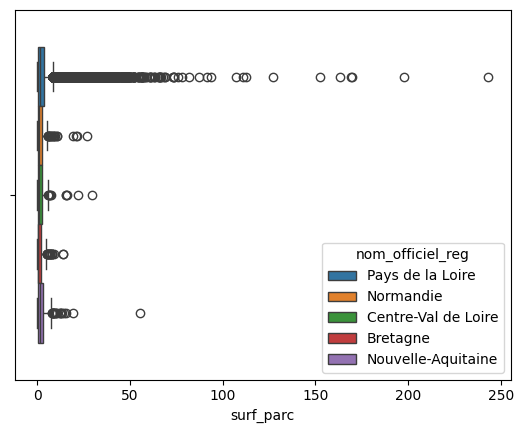

In [30]:
# Visualisation des surfaces parcelles*
sns.boxplot(rpg_avec_admin, x="surf_parc", hue="nom_officiel_reg")

In [34]:
rpg_avec_admin["nom_officiel_en_majuscules"].unique()[:50]

array(['SAINT-MARS-LA-BRIERE', 'BRISSAC LOIRE AUBANCE', 'LES HERBIERS',
       'CHANGE', 'BEAUPREAU-EN-MAUGES', 'ESSARTS-EN-BOCAGE', 'MAZE-MILON',
       'BLAISON-SAINT-SULPICE', 'LYS-HAUT-LAYON', 'BELLEVIGNE-EN-LAYON',
       'LONGUENEE-EN-ANJOU', 'CHEMILLE-EN-ANJOU', 'RIVES-DU-FOUGERAIS',
       'MAUGES-SUR-LOIRE', 'CHAILLE-LES-MARAIS', 'CHAMPAGNE-LES-MARAIS',
       "SAINT-MICHEL-EN-L'HERM", 'MONTAIGU-VENDEE', 'DOMPIERRE-SUR-YON',
       'VIEILLEVIGNE', 'FALLERON', 'DERVAL', 'VARENNES-SUR-LOIRE',
       'DEGRE', 'VAL-AU-PERCHE', 'SAINT-JEAN-DES-ECHELLES', 'MELLERAY',
       'VIVY', 'SAINT-LEONARD-DES-BOIS', 'AUBIGNE-SUR-LAYON', 'EVRON',
       'LE HORPS', 'FOUSSAIS-PAYRE', 'BOUILLE-COURDAULT',
       'SAINT-PIERRE-LE-VIEUX', 'DAMVIX', 'MAILLEZAIS',
       'DOIX LES FONTAINES', 'MAILLE', 'CHEMAZE', 'SERIGNE',
       'FONTENAY-LE-COMTE', 'SAINT-MARTIN-LARS-EN-SAINTE-HERMINE',
       'LIVRE-LA-TOUCHE', 'MONTFLOURS', 'LEVARE',
       'SAINT-BERTHEVIN-LA-TANNIERE', 'SAINT-MARTIN-DU-LIMET

In [30]:
# Extraction d'une commune
id = 25
nom_commune = rpg_avec_admin["nom_officiel_en_majuscules"].unique()[id]
df = rpg_avec_admin[rpg_avec_admin["nom_officiel_en_majuscules"] == nom_commune]

/tmp/ipykernel_6137/700373028.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


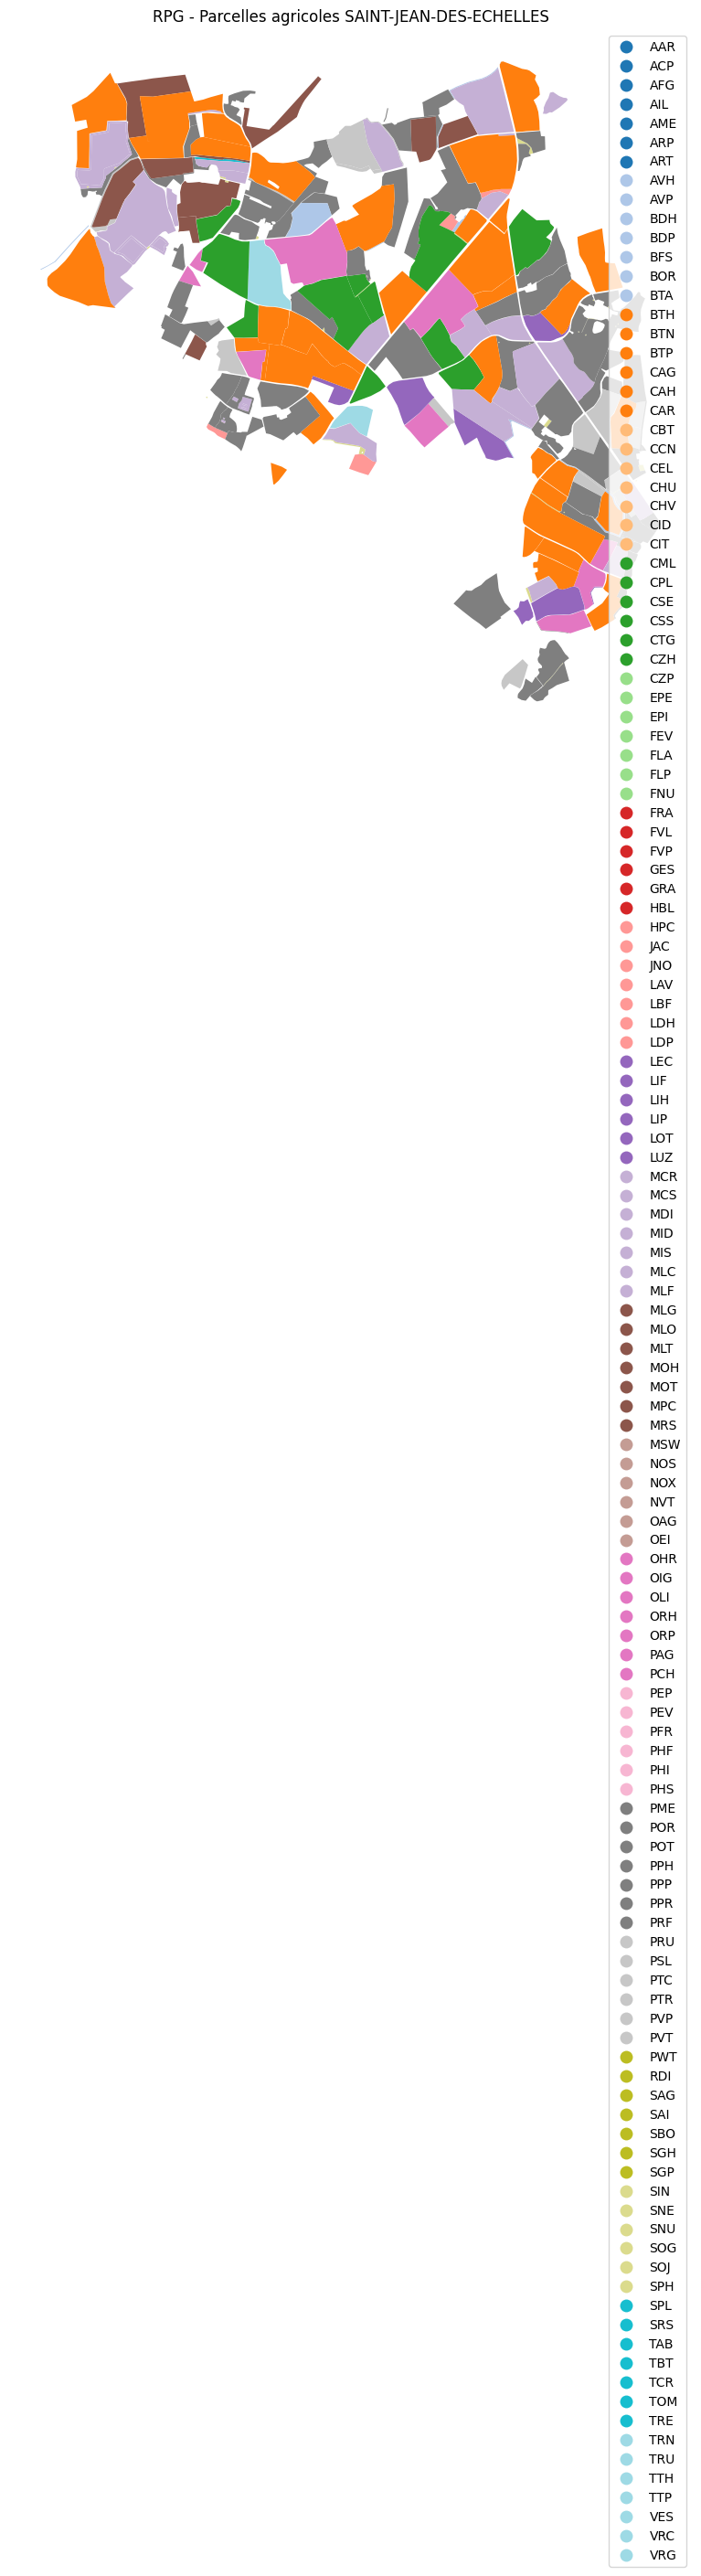

In [31]:
# Représentation sous forme de carte
fig, ax = plt.subplots(figsize=(12, 10))
df.plot(
    column="code_cultu",
    cmap="tab20",
    legend=True,
    ax=ax,
    markersize=0.5
)
ax.set_title(f"RPG - Parcelles agricoles {nom_commune}")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{nom_commune}.png", dpi=150)
plt.show()

## ANALYSE SUR LES COMMUNE

In [32]:
liste_communes = rpg_avec_admin["nom_officiel_en_majuscules"].unique()

In [33]:
# Resumé sur les communes
rows = []
for commune in liste_communes:
    df=rpg_avec_admin[rpg_avec_admin["nom_officiel_en_majuscules"] == commune]
    SAU_tot = df.surf_parc.sum()
    nb_parc = df.id_parcel.nunique()
    nb_cult = df.code_cultu.nunique()
    nb_code_cult = df.code_group.nunique()
    cult_maj = df.code_cultu.value_counts().idxmax()

    rows.append({
        "nom_commune":  commune,
        "SAU_tot":      SAU_tot,
        "nb_parc":      nb_parc,
        "nb_cult":      nb_cult,
        "cult_maj":     cult_maj
    })

df_commune = pl.DataFrame(rows)

In [34]:
# Dataframe résumé des communes
df_commune

nom_commune,SAU_tot,nb_parc,nb_cult,cult_maj
str,f64,i64,i64,str
"""SAINT-MARS-LA-BRIERE""",299.44,153,22,"""PPH"""
"""BRISSAC LOIRE AUBANCE""",7077.88,3665,62,"""VRC"""
"""LES HERBIERS""",5453.15,2222,50,"""PPH"""
"""CHANGE""",2094.58,723,32,"""PPH"""
"""BEAUPREAU-EN-MAUGES""",16691.19,6486,63,"""PPH"""
…,…,…,…,…
"""SAINT-SEBASTIEN-SUR-LOIRE""",18.71,4,1,"""PPH"""
"""SAINT-LEGER-SUR-SARTHE""",5.41,1,1,"""PPH"""
"""LA SELLE-GUERCHAISE""",13.64,2,2,"""MIS"""


In [35]:
# Séparer géométries et attributs des parcelles
geometries = rpg_avec_admin[geom_cols]  # Series shapely
parcelles = pl.from_pandas(rpg_avec_admin.drop(columns=geom_cols))  # Polars pour les calculs

In [36]:
# Calculs agrégés sur les communes
surf_parc = parcelles.group_by(
    [
        "nom_officiel_en_majuscules_reg", 
        "nom_officiel_en_majuscules_dep", 
        "nom_officiel_en_majuscules", 
        "code_group", "code_cultu"
        ]).agg([
    pl.col("surf_parc").sum().alias("SAU_tot"),
    pl.col("surf_parc").mean().alias("SAU_moy"),
    pl.len().alias("nb_parc")
])

In [37]:
# Verification du calcul des surfaces totales des parcelles
check = (
    parcelles.group_by("nom_officiel_en_majuscules")
    .agg(pl.col("surf_parc").sum().alias("SAU_tot"))
    .join(
        df_commune.rename({"nom_commune": "nom_officiel_en_majuscules"}),
        on="nom_officiel_en_majuscules"
    )
    .with_columns(
        (pl.col("SAU_tot").round(3) == pl.col("SAU_tot_right").round(3)).alias("match")
    )
)

all_match = check["match"].all()
print(all_match)

True


In [38]:
# Export du fichier 
region_rename = region.title().replace(" ", "").replace("-", "")
surf_parc.write_parquet(f"../../data/Surf_par_culture_{region_rename}.parquet")

In [114]:
# Verif que j'ai bien tout ce qu'il faut

In [39]:
surf_parc

nom_officiel_en_majuscules_reg,nom_officiel_en_majuscules_dep,nom_officiel_en_majuscules,code_group,code_cultu,SAU_tot,SAU_moy,nb_parc
str,str,str,cat,cat,f64,f64,u32
"""PAYS DE LA LOIRE""","""LOIRE-ATLANTIQUE""","""MACHECOUL-SAINT-MEME""","""8""","""PHF""",13.06,4.353333,3
"""NOUVELLE-AQUITAINE""","""DEUX-SEVRES""","""SAINT-MAIXENT-DE-BEUGNE""","""1""","""BTH""",10.02,5.01,2
"""PAYS DE LA LOIRE""","""MAYENNE""","""LA SELLE-CRAONNAISE""","""4""","""AVH""",3.53,3.53,1
"""PAYS DE LA LOIRE""","""SARTHE""","""GREEZ-SUR-ROC""","""1""","""BTH""",237.09,5.92725,40
"""PAYS DE LA LOIRE""","""LOIRE-ATLANTIQUE""","""OUDON""","""28""","""BOR""",1.12,0.124444,9
…,…,…,…,…,…,…,…
"""PAYS DE LA LOIRE""","""LOIRE-ATLANTIQUE""","""LE BIGNON""","""16""","""MLG""",154.06,3.144082,49
"""PAYS DE LA LOIRE""","""VENDEE""","""MARTINET""","""16""","""MLG""",85.63,5.351875,16
"""PAYS DE LA LOIRE""","""LOIRE-ATLANTIQUE""","""AIGREFEUILLE-SUR-MAINE""","""17""","""SPH""",0.46,0.23,2


<Axes: xlabel='SAU_tot'>

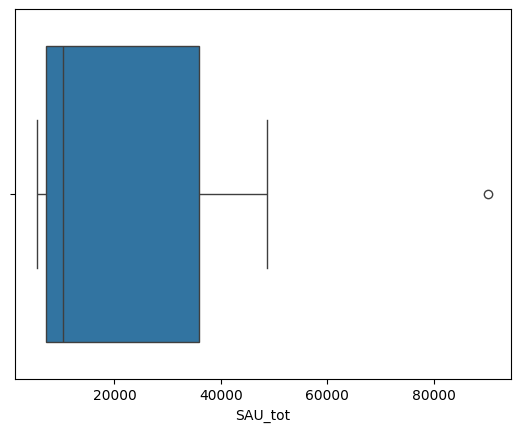

In [40]:
sns.boxplot(surf_parc.filter(pl.col("SAU_tot")> 5000), x="SAU_tot")

In [41]:
surf_parc.filter(pl.col("nom_officiel_en_majuscules") == nom_commune)

nom_officiel_en_majuscules_reg,nom_officiel_en_majuscules_dep,nom_officiel_en_majuscules,code_group,code_cultu,SAU_tot,SAU_moy,nb_parc
str,str,str,cat,cat,f64,f64,u32
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""28""","""BTA""",1.37,0.137,10
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""16""","""LUZ""",20.24,2.891429,7
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""16""","""TRE""",0.35,0.35,1
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""4""","""AVH""",4.1,4.1,1
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""28""","""SNE""",1.52,0.049032,31
…,…,…,…,…,…,…,…
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""4""","""TTH""",11.14,5.57,2
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""18""","""PPH""",154.15,2.802727,55
"""PAYS DE LA LOIRE""","""SARTHE""","""SAINT-JEAN-DES-ECHELLES""","""16""","""MLG""",37.57,3.757,10
